In [22]:
import pandas as pd

In [23]:
df = pd.read_csv("HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [24]:
left = df[df.left == 1]
left.shape

(3571, 10)

In [25]:
retained = df[df.left == 0]
retained.shape

(11428, 10)

In [26]:
df.groupby('left').mean(numeric_only = True)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


In [27]:
df.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_monthly_hours      int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                object
salary                    object
dtype: object

In [12]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [28]:
df.groupby('salary')['left'].mean()

salary
high      0.066289
low       0.296884
medium    0.204313
Name: left, dtype: float64

In [29]:
import matplotlib.pyplot as plt
import numpy as np


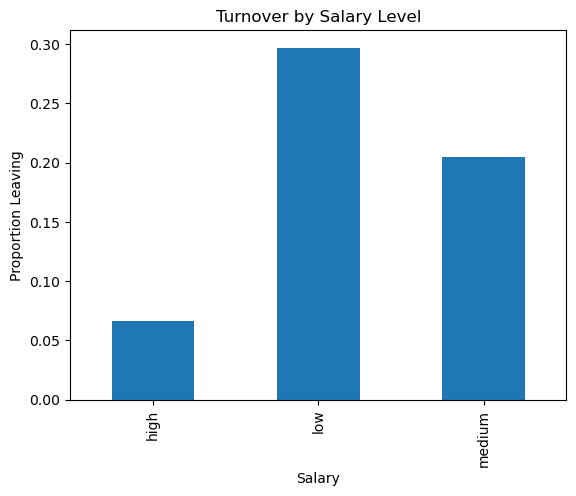

In [30]:
df.groupby('salary')['left'].mean().plot(kind = 'bar')
plt.title("Turnover by Salary Level")
plt.ylabel("Proportion Leaving")
plt.xlabel("Salary")
plt.show()

In [31]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

<Axes: title={'center': 'average_monthly_hours'}, xlabel='left'>

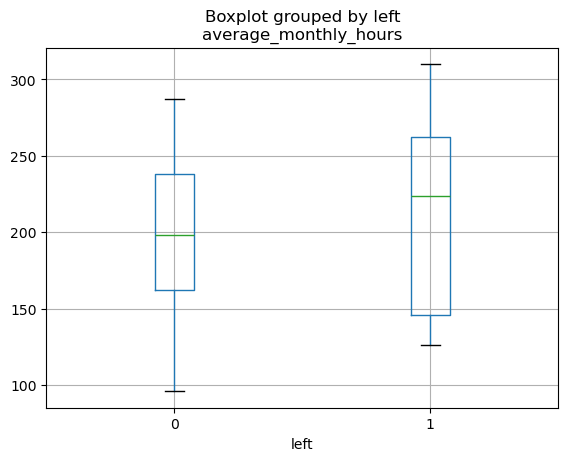

In [32]:
df.boxplot(column = 'average_monthly_hours', by = 'left')

In [33]:
df.groupby('left')['average_monthly_hours'].mean()

left
0    199.060203
1    207.419210
Name: average_monthly_hours, dtype: float64

In [35]:
df.groupby(['number_project', 'left'])['average_monthly_hours'].mean()

number_project  left
2               0       187.125457
                1       146.310147
3               0       197.119257
                1       218.986111
4               0       201.305106
                1       242.041565
5               0       203.094928
                1       243.547386
6               0       199.017341
                1       270.132824
7               1       276.078125
Name: average_monthly_hours, dtype: float64

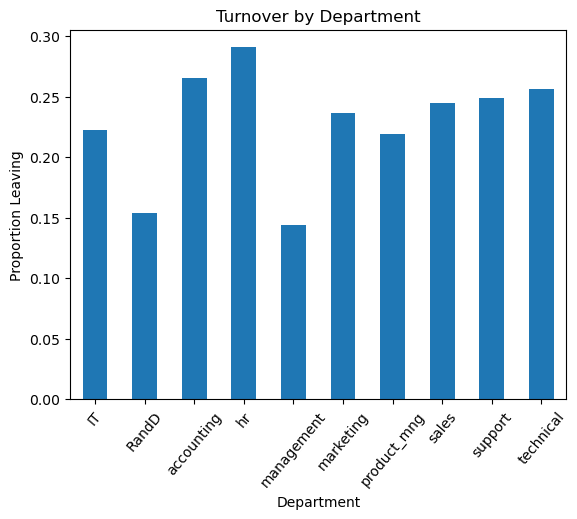

In [42]:
df.groupby('Department')['left'].mean().plot(kind = 'bar')
plt.title("Turnover by Department")
plt.ylabel("Proportion Leaving")
plt.xlabel("Department")
plt.xticks(rotation = 50)
plt.show()

In [44]:
subdf = df[['satisfaction_level', 'average_monthly_hours', 'promotion_last_5years', 'salary']]
subdf.head()

,satisfaction_level,average_monthly_hours,promotion_last_5years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low


In [45]:
salary_dummies = pd.get_dummies(subdf.salary, prefix = "salary")

In [46]:
df_with_dummies = pd.concat([subdf, salary_dummies], axis = 'columns')

In [47]:
df_with_dummies.head()

,satisfaction_level,average_monthly_hours,promotion_last_5years,salary,salary_high,salary_low,salary_medium
0,0.38,157,0,low,False,True,False
1,0.80,262,0,medium,False,False,True
2,0.11,272,0,medium,False,False,True
3,0.72,223,0,low,False,True,False
4,0.37,159,0,low,False,True,False


In [48]:
df_with_dummies.drop('salary', axis = 'columns', inplace = True)
df_with_dummies.head()

,satisfaction_level,average_monthly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,False,True,False
1,0.80,262,0,False,False,True
2,0.11,272,0,False,False,True
3,0.72,223,0,False,True,False
4,0.37,159,0,False,True,False


In [49]:
X = df_with_dummies
X.head()

,satisfaction_level,average_monthly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,False,True,False
1,0.80,262,0,False,False,True
2,0.11,272,0,False,False,True
3,0.72,223,0,False,True,False
4,0.37,159,0,False,True,False


In [50]:
y = df.left

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.2)

In [54]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 1000)

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [58]:
model.fit(X_scaled, y)

LogisticRegression(max_iter=1000)

In [59]:
model.predict(X_scaled)

array([0, 0, 1, ..., 0, 1, 0], dtype=int64)

In [61]:
# 78% accuracy:
model.score(X_scaled, y)

0.7753850256683779

In [62]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_scaled)
accuracy_score(y, y_pred)

0.7753850256683779

In [63]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y, y_pred)

array([[10700,   728],
       [ 2641,   930]], dtype=int64)